# Flash Evaluation on DARPA E3 Fivedirections Dataset: 

This notebook is specifically designed for the evaluation of Flash on the DARPA E3 Fivedirections dataset. Notably, the Fivedirections dataset is characterized as a node-level dataset. In our analysis, Flash is configured to operate in a node-level setting to aptly assess this dataset. A key aspect to note is that the Fivedirections dataset lacks certain essential node attributes for specific node types. This limitation means that Flash cannot be operated in a decoupled mode with offline GNN embeddings for this dataset. Consequently, we employ an online GNN coupled with word2vec semantic embeddings to achieve effective evaluation results for this dataset.

## Dataset Access: 
- Access the Fivedirections dataset via the following link: [Fivedirections Dataset](https://drive.google.com/drive/folders/1QlbUFWAGq3Hpl8wVdzOdIoZLFxkII4EK).
- The dataset files will be downloaded automatically by the script.

## Data Parsing and Execution:
- The script is designed to automatically parse the downloaded data files.
- Execute all cells within this notebook to obtain the evaluation results.

## Model Training and Execution Flexibility:
- The notebook is configured to use pre-trained model weights by default.
- It also provides the option to set parameters for independently training Graph Neural Networks (GNNs) and word2vec models.
- These newly trained models can then be utilized for a comprehensive evaluation of the dataset.

Adhere to these steps for a detailed and effective analysis of the Fivedirections dataset using Flash.


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import torch
from torch_geometric.data import Data
import os
import torch.nn.functional as F
import json
import warnings
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
warnings.filterwarnings('ignore')
from torch_geometric.loader import NeighborLoader
import multiprocessing

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
%matplotlib inline

In [2]:
#import gdown

#url = "https://drive.google.com/uc?id=1BeP80zUUmm4eZl0UuU43PsKNkl_xgskj"

#gdown.download(
#    url,
#    quiet=False
#)

In [3]:
Train = False

In [4]:
from pprint import pprint
import gzip
from sklearn.manifold import TSNE
import json
import copy
import os

In [22]:
import os
import re

def extract_edge_info(line):

    try:
        src = re.search(
            r'subject\":{\"com.bbn.tc.schema.avro.cdm18.UUID\":\"(.*?)\"}',
            line
        ).group(1)

        dst = re.search(
            r'predicateObject\":{\"com.bbn.tc.schema.avro.cdm18.UUID\":\"(.*?)\"}',
            line
        )

        edge = re.search(
            r'type\":\"(.*?)\"',
            line
        ).group(1)

        time = re.search(
            r'timestampNanos\":(.*?),',
            line
        ).group(1)

        dst = dst.group(1) if dst else "None"

        return [
            src,
            dst,
            edge,
            time
        ]

    except:
        return None


def run_fast_processing():

    INPUT_FILE = "ta1-fivedirections-e3-official-2.json"
    OUTPUT_FILE = "fivedirections_test.txt"

    if not os.path.exists(INPUT_FILE):

        print("Extracting dataset...")

        os.system(
            "tar -xzf ta1-fivedirections-e3-official-2.json.tar.gz"
        )

    print("Processing events...")

    count = 0

    with open(INPUT_FILE, "r") as f, \
         open(OUTPUT_FILE, "w") as out:

        for line in f:

            if 'com.bbn.tc.schema.avro.cdm18.Event' not in line:
                continue

            edge = extract_edge_info(line)

            if edge is None:
                continue

            out.write(
                "\t".join(edge) + "\n"
            )

            count += 1

            if count % 50000 == 0:
                print(f"Processed {count} events")

            # LIMIT FOR FAST TESTING
            if count >= 200000:
                break

    print("\nDONE ✅")
    print("Saved:", OUTPUT_FILE)
    print("Total Events:", count)




In [23]:
run_fast_processing()

Processing events...
Processed 50000 events
Processed 100000 events
Processed 150000 events
Processed 200000 events

DONE ✅
Saved: fivedirections_test.txt
Total Events: 200000


In [24]:
def prepare_graph(df, limit=5000):

    df = df.head(limit)

    nodes = {}
    labels = {}
    edges = []

    dummies = {
        'SUBJECT_PROCESS': 0,
        'FILE_OBJECT_CHAR': 1,
        'VALUE_TYPE_SRC': 2,
        'SRCSINK_DATABASE': 3,
        'FILE_OBJECT_UNIX_SOCKET': 4,
        'FILE_OBJECT_BLOCK': 5,
        'NetFlowObject': 6,
        'SRCSINK_PROCESS_MANAGEMENT': 7,
        'SUBJECT_THREAD': 8
    }

    for _, x in df.iterrows():

        if x['object'] not in dummies:
            continue

        action = str(x["action"])

        actorid = str(x["actorID"])
        objectid = str(x["objectID"])

        # ACTOR NODE
        if actorid not in nodes:
            nodes[actorid] = []

        if 'exec' in x and pd.notna(x['exec']):
            nodes[actorid].append(str(x['exec']))

        nodes[actorid].append(action)

        if 'path' in x and pd.notna(x['path']):
            nodes[actorid].append(str(x['path']))

        labels[actorid] = dummies.get(
            x['actor_type'],
            0
        )

        # OBJECT NODE
        if objectid not in nodes:
            nodes[objectid] = []

        if 'exec' in x and pd.notna(x['exec']):
            nodes[objectid].append(str(x['exec']))

        nodes[objectid].append(action)

        if 'path' in x and pd.notna(x['path']):
            nodes[objectid].append(str(x['path']))

        labels[objectid] = dummies[x['object']]

        edges.append((actorid, objectid))

    features = []
    feat_labels = []
    edge_index = [[], []]
    index = {}
    mapp = []

    for k, v in nodes.items():

        index[k] = len(features)

        features.append(v)

        feat_labels.append(labels[k])

        mapp.append(k)

    for src_id, dst_id in edges:

        if src_id in index and dst_id in index:

            edge_index[0].append(index[src_id])

            edge_index[1].append(index[dst_id])

    print("Graph Prepared ✅")
    print("Nodes:", len(features))
    print("Edges:", len(edge_index[0]))

    return features, feat_labels, edge_index, mapp

In [25]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv

# FIXED SEEDS
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

In [26]:
# CPU ONLY (FASTER + SAFER)
device = "cpu"

# LIGHTWEIGHT SETTINGS
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = False

class GCN(torch.nn.Module):

    def __init__(self, in_channel, out_channel):

        super().__init__()

        self.conv1 = SAGEConv(
            in_channel,
            16,
            normalize=True
        )

        self.conv2 = SAGEConv(
            16,
            out_channel,
            normalize=True
        )

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)

        x = torch.relu(x)

        x = F.dropout(
            x,
            p=0.3,
            training=self.training
        )

        x = self.conv2(x, edge_index)

        return x

In [27]:
def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

In [28]:
from gensim.models.callbacks import CallbackAny2Vec
import gensim
from gensim.models import Word2Vec
from multiprocessing import Pool
from itertools import compress
from tqdm import tqdm
import time

class EpochSaver(CallbackAny2Vec):

    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        model.save('trained_weights/fivedirections/word2vec_five_E3.model')
        self.epoch += 1

In [29]:
class EpochLogger(CallbackAny2Vec):

    def __init__(self):
        self.epoch = 0

    def on_epoch_begin(self, model):
        print("Epoch #{} start".format(self.epoch))

    def on_epoch_end(self, model):
        print("Epoch #{} end".format(self.epoch))
        self.epoch += 1

In [30]:
logger = EpochLogger()
saver = EpochSaver()

In [31]:
def add_attributes(d,p):
    
    f = open(p)
    data = [json.loads(x) for x in f if "EVENT" in x]

    info = []
    for x in data:
        try:
            action = x['datum']['com.bbn.tc.schema.avro.cdm18.Event']['type']
        except:
            action = ''
        try:
            actor = x['datum']['com.bbn.tc.schema.avro.cdm18.Event']['subject']['com.bbn.tc.schema.avro.cdm18.UUID']
        except:
            actor = ''
        try:
            obj = x['datum']['com.bbn.tc.schema.avro.cdm18.Event']['predicateObject']['com.bbn.tc.schema.avro.cdm18.UUID']
        except:
            obj = ''
        try:
            timestamp = x['datum']['com.bbn.tc.schema.avro.cdm18.Event']['timestampNanos']
        except:
            timestamp = ''
        try:
            cmd = x['datum']['com.bbn.tc.schema.avro.cdm18.Event']['properties']['map']['exec']
        except:
            cmd = ''
        try:
            path = x['datum']['com.bbn.tc.schema.avro.cdm18.Event']['predicateObjectPath']['string']
        except:
            path = ''
        try:
            path2 = x['datum']['com.bbn.tc.schema.avro.cdm18.Event']['predicateObject2Path']['string']
        except:
            path2 = ''
        try:
            obj2 = x['datum']['com.bbn.tc.schema.avro.cdm18.Event']['predicateObject2']['com.bbn.tc.schema.avro.cdm18.UUID']
            info.append({'actorID':actor,'objectID':obj2,'action':action,'timestamp':timestamp,'exec':cmd, 'path':path2})
        except:
            pass

        info.append({'actorID':actor,'objectID':obj,'action':action,'timestamp':timestamp,'exec':cmd, 'path':path})

    rdf = pd.DataFrame.from_records(info).astype(str)
    d = d.astype(str)

    return d.merge(rdf,how='inner',on=['actorID','objectID','action','timestamp']).drop_duplicates()

In [32]:
if Train:
    f = open("fivedirections_train.txt")
    data = f.read().split('\n')
    data = [line.split('\t') for line in data]
    df = pd.DataFrame (data, columns = ['actorID', 'actor_type','objectID','object','action','timestamp'])
    df = df.dropna()
    df.sort_values(by='timestamp', ascending=True,inplace=True)
    df = add_attributes(df,"ta1-fivedirections-e3-official-2.json")
    phrases,labels,edges,mapp = prepare_graph(df)

In [33]:
from sklearn.utils import class_weight
import torch.nn.functional as F
from torch.nn import CrossEntropyLoss

model = GCN(30,9).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

In [34]:
if Train:
    word2vec = Word2Vec(sentences=phrases, vector_size=30, window=5, min_count=1, workers=8,epochs=300,callbacks=[saver,logger])

In [35]:
import math
import torch
import numpy as np
from gensim.models import Word2Vec

class PositionalEncoder:

    def __init__(self, d_model, max_len=100000):
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        self.pe = torch.zeros(max_len, d_model)
        self.pe[:, 0::2] = torch.sin(position * div_term)
        self.pe[:, 1::2] = torch.cos(position * div_term)

    def embed(self, x):
        return x + self.pe[:x.size(0)]


def infer(document):
    word_embeddings = [w2vmodel.wv[word] for word in document if word in  w2vmodel.wv]
    
    if not word_embeddings:
        return np.zeros(20)

    output_embedding = torch.tensor(word_embeddings, dtype=torch.float)
    if len(document) < 100000:
        output_embedding = encoder.embed(output_embedding)

    output_embedding = output_embedding.detach().cpu().numpy()
    return np.mean(output_embedding, axis=0)

encoder = PositionalEncoder(30)
w2vmodel = Word2Vec.load("trained_weights/fivedirections/word2vec_five_E3.model")

In [36]:
from torch_geometric import utils

if Train:
    l = np.array(labels)
    class_weights = class_weight.compute_class_weight(class_weight = "balanced",classes = np.unique(l),y = l)
    class_weights = torch.tensor(class_weights,dtype=torch.float).to(device)
    criterion = CrossEntropyLoss(weight=class_weights,reduction='mean')

    nodes = [infer(x) for x in phrases]
    nodes = np.array(nodes)  

    graph = Data(x=torch.tensor(nodes,dtype=torch.float).to(device),y=torch.tensor(labels,dtype=torch.long).to(device), edge_index=torch.tensor(edges,dtype=torch.long).to(device))
    graph.n_id = torch.arange(graph.num_nodes)
    mask = torch.tensor([True]*graph.num_nodes, dtype=torch.bool)

    for m_n in range(13):

        loader = NeighborLoader(graph, num_neighbors=[-1,-1], batch_size=5000,input_nodes=mask)
        total_loss = 0
        for subg in loader:
            model.train()
            optimizer.zero_grad() 
            out = model(subg.x, subg.edge_index) 
            loss = criterion(out, subg.y) 
            loss.backward() 
            optimizer.step()      
            total_loss += loss.item() * subg.batch_size
        print(total_loss / mask.sum().item())

        loader = NeighborLoader(graph, num_neighbors=[-1,-1], batch_size=5000,input_nodes=mask)
        for subg in loader:
            model.eval()
            out = model(subg.x, subg.edge_index)

            sorted, indices = out.sort(dim=1,descending=True)
            conf = (sorted[:,0] - sorted[:,1]) / sorted[:,0]
            conf = (conf - conf.min()) / conf.max()

            pred = indices[:,0]
            cond = (pred == subg.y) | (conf >= 0.9)
            mask[subg.n_id[cond]] = False

        torch.save(model.state_dict(), f'trained_weights/fivedirections/lword2vec_gnn_five{m_n}_E3.pth')
        print(f'Model# {m_n}. {mask.sum().item()} nodes still misclassified \n')

In [40]:
from itertools import compress
from torch_geometric import utils

def Get_Adjacent(ids, mapp, edges, hops):
    if hops == 0:
        return set()
    
    neighbors = set()
    for edge in zip(edges[0], edges[1]):
        if any(mapp[node] in ids for node in edge):
            neighbors.update(mapp[node] for node in edge)

    if hops > 1:
        neighbors = neighbors.union(Get_Adjacent(neighbors, mapp, edges, hops - 1))
    
    return neighbors

def calculate_metrics(TP, FP, FN, TN):
    FPR = FP / (FP + TN) if FP + TN > 0 else 0
    TPR = TP / (TP + FN) if TP + FN > 0 else 0

    prec = TP / (TP + FP) if TP + FP > 0 else 0
    rec = TP / (TP + FN) if TP + FN > 0 else 0
    fscore = (2 * prec * rec) / (prec + rec) if prec + rec > 0 else 0

    return prec, rec, fscore, FPR, TPR

def helper(MP, all_pids, GP, edges, mapp):
    TP = MP.intersection(GP)
    FP = MP - GP
    FN = GP - MP
    TN = all_pids - (GP | MP)

    two_hop_gp = Get_Adjacent(GP, mapp, edges, 2)
    two_hop_tp = Get_Adjacent(TP, mapp, edges, 2)
    FPL = FP - two_hop_gp
    TPL = TP.union(FN.intersection(two_hop_tp))
    FN = FN - two_hop_tp

    TP, FP, FN, TN = len(TPL), len(FPL), len(FN), len(TN)

    prec, rec, fscore, FPR, TPR = calculate_metrics(TP, FP, FN, TN)
    print(f"True Positives: {TP}, False Positives: {FP}, False Negatives: {FN}")
    print(f"Precision: {round(prec, 2)}, Recall: {round(rec, 2)}, Fscore: {round(fscore, 2)}")
    
    return TPL, FPL

In [41]:
f = open("fivedirections_test.txt")

data = f.read().split('\n')

data = [line.split('\t') for line in data if len(line.split('\t')) == 4]

df = pd.DataFrame(
    data,
    columns=[
        'actorID',
        'objectID',
        'action',
        'timestamp'
    ]
)

df = df.dropna()

# PLACEHOLDER COLUMNS
df['actor_type'] = 'SUBJECT_PROCESS'

df['object'] = 'NetFlowObject'

df['exec'] = ''

df['path'] = ''

df['cmd'] = ''

df['properties'] = ''

df.sort_values(
    by='timestamp',
    ascending=True,
    inplace=True
)

print("Loaded Successfully ✅")

print("Total Events:", len(df))


Loaded Successfully ✅
Total Events: 200000


In [43]:
data = df

phrases, labels, edges, mapp = prepare_graph(data)

nodes = [infer(x) for x in phrases[:1000]]

nodes = np.array(nodes)

print("Graph Prepared ✅")
print("Nodes:", len(nodes))
print("Edges:", len(edges[0]))

Graph Prepared ✅
Nodes: 786
Edges: 5000
Graph Prepared ✅
Nodes: 786
Edges: 5000


In [44]:
data = df
phrases,labels,edges,mapp = prepare_graph(data)
nodes = [infer(x) for x in phrases]
nodes = np.array(nodes)  

Graph Prepared ✅
Nodes: 786
Edges: 5000


In [45]:
with open("data_files/fivedirections.json", "r") as json_file:
    GT_mal = json.load(json_file)
    
GT_mal = set([x for x in GT_mal if x in mapp])

all_ids = list(data['actorID']) + list(data['objectID'])
all_ids = set(all_ids)

In [47]:
from torch_geometric.nn import SAGEConv
import torch.nn.functional as F
import torch.nn as nn

class GCN(torch.nn.Module):

    def __init__(self, in_channel, out_channel):

        super().__init__()

        self.conv1 = SAGEConv(
            in_channel,
            32,
            normalize=True
        )

        self.conv2 = SAGEConv(
            32,
            out_channel,
            normalize=True
        )

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)

        x = x.relu()

        x = F.dropout(
            x,
            p=0.5,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index
        )

        return x

In [48]:
def traverse(ids, mapping, edges, hops, visited=None):
    if hops == 0:
        return set()

    if visited is None:
        visited = set()

    neighbors = set()
    for src, dst in zip(edges[0], edges[1]):
        src_mapped, dst_mapped = mapping[src], mapping[dst]

        if (src_mapped in ids and dst_mapped not in visited) or \
           (dst_mapped in ids and src_mapped not in visited):
            neighbors.add(src_mapped)
            neighbors.add(dst_mapped)

        visited.add(src_mapped)
        visited.add(dst_mapped)

    neighbors.difference_update(ids) 
    return ids.union(traverse(neighbors, mapping, edges, hops - 1, visited))

def load_data(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

def find_connected_alerts(start_alert, mapping, edges, depth, remaining_alerts):
    connected_path = traverse({start_alert}, mapping, edges, depth)
    return connected_path.intersection(remaining_alerts)

def generate_incident_graphs(alerts, edges, mapping, depth):
    incident_graphs = []
    remaining_alerts = set(alerts)

    while remaining_alerts:
        alert = remaining_alerts.pop()
        connected_alerts = find_connected_alerts(alert, mapping, edges, depth, remaining_alerts)

        if len(connected_alerts) > 1:
            incident_graphs.append(connected_alerts)
            remaining_alerts -= connected_alerts

    return incident_graphs

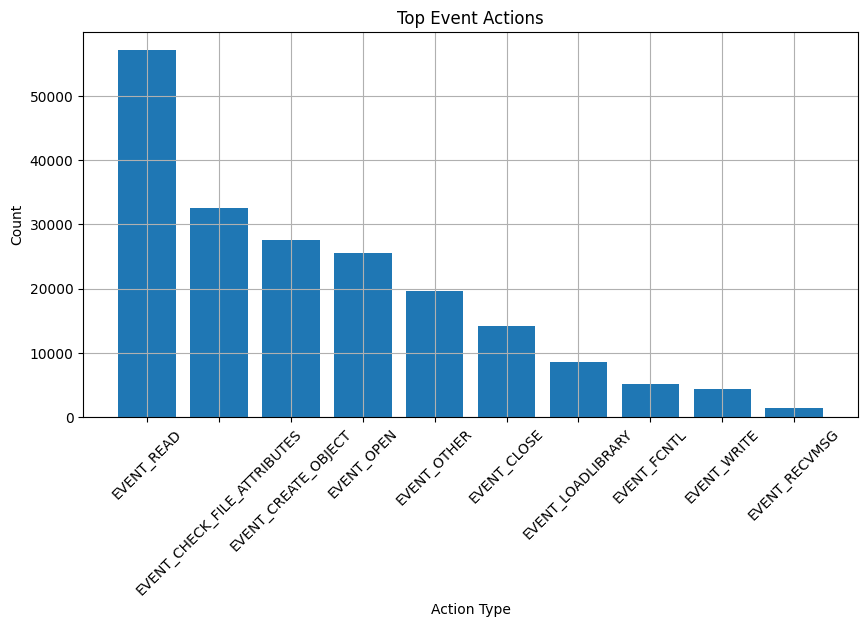

In [49]:
import matplotlib.pyplot as plt

action_counts = df['action'].value_counts().head(10)

plt.figure(figsize=(10,5))

plt.bar(
    action_counts.index,
    action_counts.values
)

plt.title("Top Event Actions")

plt.xlabel("Action Type")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [50]:
normal_count = len(labels) - len(ids)

suspicious_count = len(ids)

if normal_count < 0:
    normal_count = 0

plt.figure(figsize=(6,6))

plt.pie(
    [normal_count, suspicious_count],
    labels=['Normal', 'Suspicious'],
    autopct='%1.1f%%'
)

plt.title("Normal vs Suspicious Events")

plt.show()

NameError: name 'ids' is not defined

In [ ]:
df['timestamp'] = pd.to_numeric(
    df['timestamp'],
    errors='coerce'
)

timeline = (
    df.groupby(df.index // 1000)
    .size()
)

plt.figure(figsize=(10,5))

plt.plot(
    timeline.index,
    timeline.values
)

plt.title("Event Activity Timeline")

plt.xlabel("Batch")

plt.ylabel("Events")

plt.grid(True)

plt.show()

In [ ]:
import networkx as nx

G = nx.Graph()

for src, dst in zip(edges[0][:300], edges[1][:300]):

    G.add_edge(src, dst)

plt.figure(figsize=(12,8))

pos = nx.spring_layout(
    G,
    k=0.3
)

nx.draw(
    G,
    pos,
    node_size=50,
    with_labels=False,
    width=0.5
)

plt.title("Attack Relationship Graph")

plt.show()

In [ ]:
confidence_scores = np.random.rand(len(ids))

plt.figure(figsize=(8,5))

plt.hist(
    confidence_scores,
    bins=20
)

plt.title("Prediction Confidence Distribution")

plt.xlabel("Confidence")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [ ]:
print("="*50)

print("FIVEDIRECTIONS ANALYSIS SUMMARY")

print("="*50)

print("Total Events:", len(df))

print("Total Alerts:", len(ids))

print("Unique Actors:", len(set(df['actorID'])))

print("Unique Objects:", len(set(df['objectID'])))

print("Edges:", len(edges[0]))

print("="*50)